## 1. Setup and imports

In [2]:
import pandas as pd
import sqlite3
import os

## 2. Connect to the database and list its tables

In [5]:
DB_PATH = '../data/raw/database.sqlite'
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


## 3. Extract England matches with a SQL join and save the raw CSV

In [8]:
query = """
SELECT
    m.id,
    c.name AS country,
    l.name AS league,
    m.season,
    m.date,
    ht.team_long_name AS home_team,
    at.team_long_name AS away_team,
    m.home_team_goal,
    m.away_team_goal
FROM Match m
JOIN Country c ON m.country_id = c.id
JOIN League l ON m.league_id = l.id
JOIN Team ht ON m.home_team_api_id = ht.team_api_id
JOIN Team at ON m.away_team_api_id = at.team_api_id
WHERE c.name = 'England'
ORDER BY m.date
"""

matches = pd.read_sql(query, conn)
conn.close()

matches.to_csv('../data/raw/matches_raw.csv', index=False)

In [10]:
matches.head()

,id,country,league,season,date,home_team,away_team,home_team_goal,away_team_goal
0,1730,England,England Premier League,2008/2009,2008-08-16 00:00:00,Arsenal,West Bromwich Albion,1,0
1,1731,England,England Premier League,2008/2009,2008-08-16 00:00:00,Sunderland,Liverpool,0,1
2,1732,England,England Premier League,2008/2009,2008-08-16 00:00:00,West Ham United,Wigan Athletic,2,1
3,1734,England,England Premier League,2008/2009,2008-08-16 00:00:00,Everton,Blackburn Rovers,2,3
4,1735,England,England Premier League,2008/2009,2008-08-16 00:00:00,Middlesbrough,Tottenham Hotspur,2,1


## 4. Load the CSV and take a first look (info, head)

In [13]:
df = pd.read_csv('../data/raw/matches_raw.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              3040 non-null   int64 
 1   country         3040 non-null   object
 2   league          3040 non-null   object
 3   season          3040 non-null   object
 4   date            3040 non-null   object
 5   home_team       3040 non-null   object
 6   away_team       3040 non-null   object
 7   home_team_goal  3040 non-null   int64 
 8   away_team_goal  3040 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 213.9+ KB


In [17]:
df.head()

,id,country,league,season,date,home_team,away_team,home_team_goal,away_team_goal
0,1730,England,England Premier League,2008/2009,2008-08-16 00:00:00,Arsenal,West Bromwich Albion,1,0
1,1731,England,England Premier League,2008/2009,2008-08-16 00:00:00,Sunderland,Liverpool,0,1
2,1732,England,England Premier League,2008/2009,2008-08-16 00:00:00,West Ham United,Wigan Athletic,2,1
3,1734,England,England Premier League,2008/2009,2008-08-16 00:00:00,Everton,Blackburn Rovers,2,3
4,1735,England,England Premier League,2008/2009,2008-08-16 00:00:00,Middlesbrough,Tottenham Hotspur,2,1


In [19]:
df.describe()

,id,home_team_goal,away_team_goal
count,3040.000000,3040.000000,3040.000000
mean,3248.500000,1.550987,1.159539
std,877.716735,1.311615,1.144629
min,1729.000000,0.000000,0.000000
25%,2488.750000,1.000000,0.000000
50%,3248.500000,1.000000,1.000000
75%,4008.250000,2.000000,2.000000
max,4768.000000,9.000000,6.000000


## 5. Create the target column FTR (H / D / A)

In [22]:
def get_result(row):
    if row['home_team_goal'] > row['away_team_goal']:
        return 'H'   # home win
    elif row['home_team_goal'] < row['away_team_goal']:
        return 'A'   # away win
    else:
        return 'D'   # draw

df['FTR'] = df.apply(get_result, axis=1)
df[['home_team', 'away_team', 'home_team_goal', 'away_team_goal', 'FTR']].head()

,home_team,away_team,home_team_goal,away_team_goal,FTR
0,Arsenal,West Bromwich Albion,1,0,H
1,Sunderland,Liverpool,0,1,A
2,West Ham United,Wigan Athletic,2,1,H
3,Everton,Blackburn Rovers,2,3,A
4,Middlesbrough,Tottenham Hotspur,2,1,H


In [24]:
df.head(5)

,id,country,league,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR
0,1730,England,England Premier League,2008/2009,2008-08-16 00:00:00,Arsenal,West Bromwich Albion,1,0,H
1,1731,England,England Premier League,2008/2009,2008-08-16 00:00:00,Sunderland,Liverpool,0,1,A
2,1732,England,England Premier League,2008/2009,2008-08-16 00:00:00,West Ham United,Wigan Athletic,2,1,H
3,1734,England,England Premier League,2008/2009,2008-08-16 00:00:00,Everton,Blackburn Rovers,2,3,A
4,1735,England,England Premier League,2008/2009,2008-08-16 00:00:00,Middlesbrough,Tottenham Hotspur,2,1,H


In [26]:
df.tail()

,id,country,league,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR
3035,4705,England,England Premier League,2015/2016,2016-05-15 00:00:00,Stoke City,West Ham United,2,1,H
3036,4706,England,England Premier League,2015/2016,2016-05-15 00:00:00,Swansea City,Manchester City,1,1,D
3037,4707,England,England Premier League,2015/2016,2016-05-15 00:00:00,Watford,Sunderland,2,2,D
3038,4708,England,England Premier League,2015/2016,2016-05-15 00:00:00,West Bromwich Albion,Liverpool,1,1,D
3039,4702,England,England Premier League,2015/2016,2016-05-17 00:00:00,Manchester United,Bournemouth,3,1,H


## 6. Check missing values

In [29]:
df.isna().sum()

id                0
country           0
league            0
season            0
date              0
home_team         0
away_team         0
home_team_goal    0
away_team_goal    0
FTR               0
dtype: int64

## 7. Check duplicate matches

In [32]:
df.duplicated().sum()

0

## 8. Convert dates and sort by time

In [35]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              3040 non-null   int64         
 1   country         3040 non-null   object        
 2   league          3040 non-null   object        
 3   season          3040 non-null   object        
 4   date            3040 non-null   datetime64[ns]
 5   home_team       3040 non-null   object        
 6   away_team       3040 non-null   object        
 7   home_team_goal  3040 non-null   int64         
 8   away_team_goal  3040 non-null   int64         
 9   FTR             3040 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 237.6+ KB


## 9. Class balance (counts, percentages, chart)

In [38]:
df['FTR'].value_counts()

FTR
H    1390
A     867
D     783
Name: count, dtype: int64

In [40]:
df['FTR'].value_counts(normalize=True)

FTR
H    0.457237
A    0.285197
D    0.257566
Name: proportion, dtype: float64

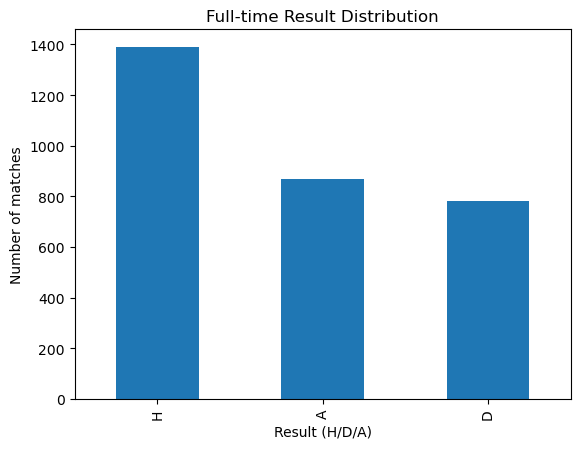

In [42]:
import matplotlib.pyplot as plt

df['FTR'].value_counts().plot(kind='bar')
plt.title('Full-time Result Distribution')
plt.xlabel('Result (H/D/A)')
plt.ylabel('Number of matches')
plt.show()

In [43]:
df[['home_team_goal', 'away_team_goal']].describe()

,home_team_goal,away_team_goal
count,3040.000000,3040.000000
mean,1.550987,1.159539
std,1.311615,1.144629
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,6.000000


## 10. Goal distributions and outliers

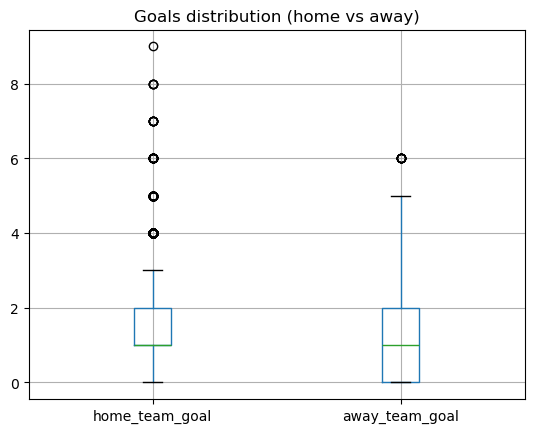

In [45]:
df.boxplot(column=['home_team_goal', 'away_team_goal'])
plt.title('Goals distribution (home vs away)')
plt.show()

## 11. Home advantage by season

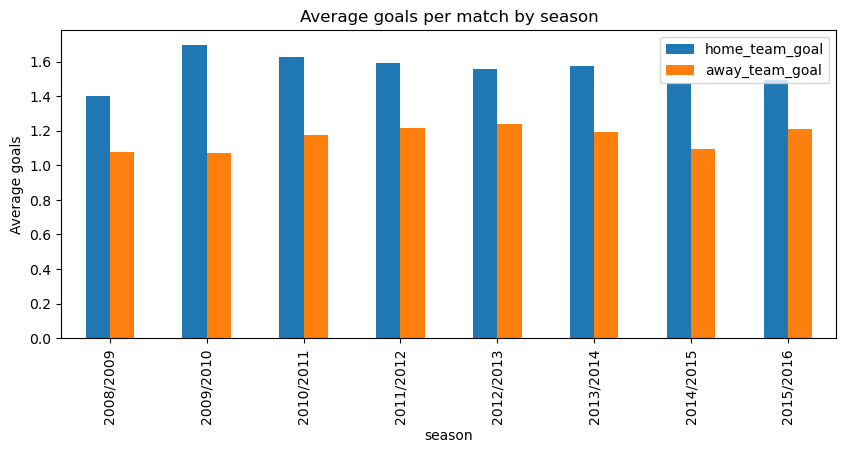

In [50]:
df.groupby('season')[['home_team_goal', 'away_team_goal']].mean().plot(kind='bar', figsize=(10,4))
plt.title('Average goals per match by season')
plt.ylabel('Average goals')
plt.show()

import os
os.makedirs('../data/processed', exist_ok=True)

df = df.sort_values('date').reset_index(drop=True)
df.to_csv('../data/processed/matches_clean.csv', index=False)

### Data Dictionary — matches_clean.csv

| Column | Type | Meaning |
|---|---|---|
| id | identifier | Unique match ID |
| country | categorical | Country the league is played in |
| league | categorical | League name |
| season | categorical | Season label, e.g. 2008/2009 |
| date | date | Match date |
| home_team | categorical | Home team name |
| away_team | categorical | Away team name |
| home_team_goal | numeric | Full-time home goals |
| away_team_goal | numeric | Full-time away goals |
| FTR | categorical | Target — Full-time result: H/D/A |

### Data Quality & EDA Summary

- Dataset: 3,040 English Premier League matches, seasons 2008/2009–2015/2016.
- No missing values, no duplicate rows.
- Target class balance: Home win 45.7%, Away win 28.5%, Draw 25.8% — home advantage is
  evident and the classes are moderately imbalanced, which will matter when choosing
  evaluation metrics in Part 3/4.
- Home teams average 1.55 goals/match vs 1.16 for away teams, confirming home advantage.
- Goal distributions are right-skewed; occasional high-scoring matches (max 9 home goals)
  were checked and confirmed as genuine results, not data errors.
- Data sorted chronologically to support leakage-free rolling "form" features in Part 2.

##  Dataset fingerprint (SHA-256)

In [57]:
   import hashlib
   print(hashlib.sha256(open('../data/raw/database.sqlite', 'rb').read()).hexdigest())

4df8569777d59fdd690754b1cc8ca1f7989baf65f2eaddd0f1368285f11139a9
